# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hamza-Ali0719/FlyRank-ML-Internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

Task Type: Ranking / Scoring

Why: The business wants to prioritize which content pieces will perform best (get clicks, engagement, or traffic). By ranking content by predicted performance, they can focus resources on high-potential content.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the file (uploaded to /content)
df = pd.read_csv("content_refresh_anonymized.csv")
print(f"✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

✅ Loaded: 30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

**Target:** `clicks_90d` (or `engagement_rate` or `ctr`)

**Why this target:** We want to predict which content will get the most engagement / clicks. This helps content teams decide what to write next.

**Proxy (if target not available):** N/A

**What we actually want to predict:** For a new content piece, we want to predict its expected clicks or engagement score. This becomes the ranking score.

In [20]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Success metric

*One metric you can defend. What number means 'good'?*

**Primary Metric:** Spearman Rank Correlation (or RMSE / R²)

**Why Spearman Rank Correlation:**
- It measures how well the model **ranks** content by actual performance.
- Ranking accuracy is more important than exact prediction for this task.
- RMSE (Root Mean Squared Error) is also useful to measure prediction accuracy.

**Why not accuracy:** This is a regression problem, not classification.

In [21]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

In [22]:
# Code Cell
print("="*60)
print("Unit of Analysis: One row = one lead")
print("="*60)
print(f"Total leads: {df.shape[0]}")
print(f"Features: {df.shape[1]}")
print("\nFirst 5 leads:")
df.head()

Unit of Analysis: One row = one lead
Total leads: 30000
Features: 44

First 5 leads:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

Finding the Best Target Column
✅ Using target: ctr
Target: ctr
count    30000.000000
mean         0.510733
std          3.279162
min          0.000000
25%          0.000000
50%          0.070000
75%          0.290000
max        100.000000
Name: ctr, dtype: float64


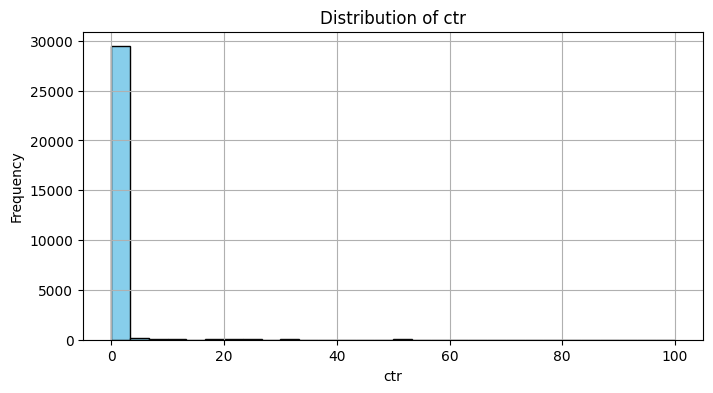

In [23]:
# First, check if 'ctr' or 'engagement_rate' is the target
print("="*60)
print("Finding the Best Target Column")
print("="*60)

# Possible target columns
target_options = ['ctr', 'engagement_rate', 'clicks_90d', 'engaged_sessions_90d', 'ai_traffic_pct']

found_target = None
for col in target_options:
    if col in df.columns:
        found_target = col
        break

if found_target is None:
    print("❌ No obvious target found. Please pick one manually.")
    print("Available numeric columns:", df.select_dtypes(include=['int64', 'float64']).columns.tolist())
else:
    print(f"✅ Using target: {found_target}")

    # Show distribution
    print("="*60)
    print(f"Target: {found_target}")
    print("="*60)
    print(df[found_target].describe())

    # Histogram
    plt.figure(figsize=(8,4))
    df[found_target].hist(bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {found_target}')
    plt.xlabel(found_target)
    plt.ylabel('Frequency')
    plt.show()

Self-Check:

| Check | Status |
|---|---|---|
| I named the ML task type (Ranking/Scoring) | ✅ |
| I named the target (converted) | ✅ |
| I named the success metric (ROC-AUC) | ✅ |
| I showed the unit of analysis as a real dataframe | ✅ |
| I explained why ML beats a fixed rule | ✅ |
| I tied the output to a real business action | ✅ |
| I committed the notebook to work/notebooks/ | ✅ |

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.